# 02 · Schema Classification — which columns become features, and how

Stage 3 of the pipeline (`scripts/classify_schema.py`). Between the split and the tokenizer, this
step reads the **train** panel and decides, for every column: is it a **feature** or a **drop**? is
it **static** (a fixed origination fact → the *profile* branch) or **dynamic** (changes every month
→ the *event* branch)? and is its value **numeric**, **categorical**, or a **flag**? The output is
the **field schema** the tokenizer then turns into tokens.

It runs on the **train split only** so any cardinality statistics stay train-only (leakage rule
DL-008) — the same discipline as fitting the vocabulary.

**Contents**
1. What this stage does
2. Role — static (profile) vs dynamic (event)
3. Type — numeric / categorical / flag / temporal / constant
4. Dropping — constant &amp; redundant (safe) vs functional-dependency (review)
5. The resulting source field schema
6. How to run it
7. Notes &amp; caveats

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import yaml

# find the repo root (walk up until we see configs/)
ROOT = Path.cwd()
while not (ROOT / "configs" / "mortgage_performance").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "configs" / "mortgage_performance").exists(), "run inside the credit-foundation-model repo"

def load_yaml(name):
    return yaml.safe_load((ROOT / "configs" / "mortgage_performance" / name).read_text())

CLASSIFY = load_yaml("classify.yaml")     # the recipe (input = train split, id/time cols, dataset:)
SCHEMA = load_yaml("tokenizer.yaml")      # the OUTPUT field schema this stage feeds
DATASET = load_yaml("dataset.yaml")       # the DATASET CONTRACT — leakage/exclude enforced from here
print("classify recipe input:", CLASSIFY.get("input"))
print("id_col / time_col     :", CLASSIFY.get("id_col"), "/", CLASSIFY.get("time_col"))
print("contract              :", CLASSIFY.get("dataset"),
      f"({len(DATASET.get('leakage', []))} leakage + {len(DATASET.get('exclude', []))} exclude cols)")

classify recipe input: ${paths.processed}/train.parquet
id_col / time_col     : loan_id / reporting_date
contract              : None (44 leakage + 15 exclude cols)


## 1. What this stage does

`classify_schema.py` is **data-driven and reproducible** — re-running it on the same train split
regenerates the same schema. Steps:

0. **Enforce the dataset contract first** — drop every `leakage:` + `exclude:` column named in
   `dataset.yaml` **before any analysis** (v1.1). An outcome-encoding column like
   `current_loan_delinquency_status` can't even become a *candidate* feature — the machine does
   this now, so it's not a thing a human has to remember.
1. **Classify each column's role** — `id` / `static` (constant within a loan) / `dynamic` (varies
   across a loan's monthly rows).
2. **Classify each column's value type** — `constant` / `temporal` / `flag` / `bucket` / `numeric`
   / `categorical` / `text`.
3. **Drop `constant` columns** — one value across the whole panel = no signal.
4. **Drop `safe` redundancies** auto-detected from the data — exact-duplicate columns and numeric
   `*_bucket` pre-discretizations (the raw is kept and re-binned by the tokenizer).
5. **Emit the profile (static) / event (dynamic) field lists**, each split by type — this is the
   schema the tokenizer consumes.

Functional-dependency candidates (`X = f(Y)`) are **not** auto-dropped — they're printed as
`review` suggestions, because some (like an explicit flag) may be wanted as signals. You opt in via
the recipe's `drop:` list.

## 2. Role — static (profile) vs dynamic (event)

The test is simple and structural: **group the panel by `loan_id`; if a column has one value within
every loan, it's static; if it changes across a loan's months, it's dynamic.** (Computed on a random
sample of loans for speed — it's a structural property, so a sample is enough.)

| Role | Meaning | Branch | mortgage examples |
|---|---|---|---|
| **static** | fixed at origination, repeats every month | **PROFILE** (emitted once per loan) | `original_ltv`, `dti`, `fico`, `loan_purpose`, `property_state` |
| **dynamic** | changes month to month | **EVENT** (emitted per monthly row) | `current_interest_rate`, `current_actual_upb`, `loan_age`, `remaining_months_to_maturity` |
| **id** | the loan key | — | `loan_id` |

This static/dynamic split is exactly what the three-branch model needs: the Profile encoder reads the
static block once, the Event encoder reads each month's dynamic block.

## 3. Type — numeric / categorical / flag / temporal / constant

Type is decided by name and cardinality (number of distinct values):

| Type | Rule | Handling downstream |
|---|---|---|
| `constant` | only 1 distinct value | **dropped** (no signal) |
| `temporal` | name ends `_date`, or is the time column | becomes the `t=` / `cal=` time coordinates |
| `flag` | name ends `_flag` | a small yes/no/NA categorical |
| `bucket` | name ends `_bucket` | pre-binned (dropped if it just discretizes a numeric raw) |
| `numeric` | numeric dtype with **> 20** distinct values | quantile-binned by the tokenizer |
| `categorical` | numeric with **≤ 20** distinct, or a low-cardinality string | one token per category |
| `text` | very high-cardinality / long strings | excluded (non-tabular) |

The `> 20` cutoff is why something like `number_of_units` (values 1–4) is treated as **categorical**
while `original_upb` (thousands of distinct dollar amounts) is **numeric** and gets binned.

## 4. Dropping — `safe` (auto) vs `review` (human)

The classifier separates two kinds of redundancy so nothing is silently lost:

* **`safe` — auto-dropped.** (a) **Exact duplicates** — two columns with identical values on the
  sample (keep one). (b) **Numeric `*_bucket`** — a pre-discretized copy of a numeric raw column;
  the raw is kept and the tokenizer re-bins it. *(A `*_bucket` with no numeric base — e.g. a genuine
  state code — is a real field and is NOT dropped.)*
* **`review` — surfaced, not dropped.** **Functional dependencies** `X = f(Y)` among low-cardinality
  columns (keep the finer `Y`). These print as suggestions; you drop them explicitly via the recipe's
  `drop:` list only if you're sure they carry no independent signal.

This "auto-drop only the unambiguous, ask about the rest" split is the whole point — reproducible
where it's safe, human-in-the-loop where judgment matters.

## 5. The resulting source field schema

Below is the field schema this stage feeds the tokenizer (`configs/mortgage_performance/tokenizer.yaml`):
every kept field, its branch (profile/event) and type (numeric/categorical). Note the counts — the
tokenizer works from a **curated ~43-field** schema built *on top of* the classifier's output (the
leakage exclusion is now machine-enforced; the remaining curation is enumerated in the honesty note
after the table).

In [2]:
def schema_rows(schema):
    rows = []
    for branch in ("profile", "event"):
        for typ, cols in (schema.get(branch) or {}).items():
            for c in (cols or []):
                rows.append({"field": c, "branch": branch, "type": typ})
    return pd.DataFrame(rows)

FIELDS = schema_rows(SCHEMA)
counts = FIELDS.groupby(["branch", "type"]).size().unstack(fill_value=0)
print(f"{len(FIELDS)} tokenized fields")
display(counts)
FIELDS

43 tokenized fields


type,categorical,numeric
branch,,
event,1,11
profile,15,16


,field,branch,type
0,original_interest_rate,profile,numeric
1,original_upb,profile,numeric
2,upb_at_issuance,profile,numeric
3,original_loan_term,profile,numeric
4,original_ltv,profile,numeric
5,original_cltv,profile,numeric
6,number_of_borrowers,profile,numeric
7,number_of_units,profile,numeric
8,dti,profile,numeric
9,borrower_credit_score_at_origination,profile,numeric


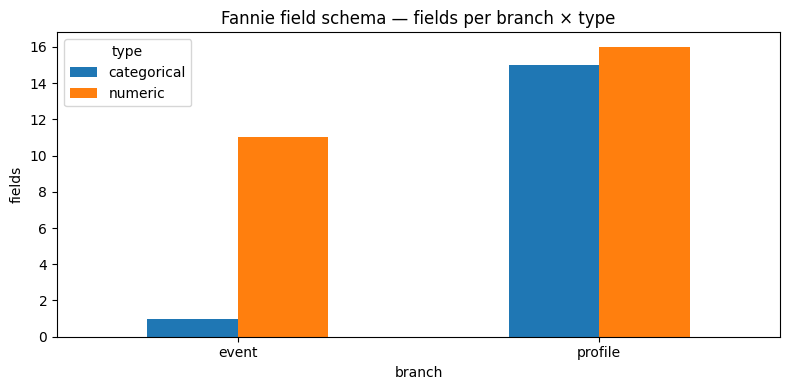

In [3]:
import matplotlib.pyplot as plt
pivot = FIELDS.groupby(["branch", "type"]).size().unstack(fill_value=0)
ax = pivot.plot(kind="bar", figsize=(8, 4))
ax.set_title("source field schema — fields per branch × type")
ax.set_xlabel("branch")
ax.set_ylabel("fields")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### ⚠️ Honesty note — leakage is machine-enforced; the rest is a *documented* review layer

**Update (v1.1):** `classify_schema.py` now reads the dataset contract and **drops every
`leakage:`/`exclude:` column before classifying** — verified on the real 254M-row train split
(44 leakage + 15 exclude columns dropped; 0 reached the schema). So the security property is no
longer "trust the curation" — it's enforced by code and covered by a test
(`tests/test_classify_schema.py`).

The Mortgage `tokenizer.yaml` above is still **curated on top of** the classifier's output, but for
reasons that are *deliberate*, not gaps — and every difference is enumerable (run
`classify_schema --out /tmp/regen.yaml` and diff):

* **Slice-superset fields.** The curated schema is the contract for the *full published layout*, so
  it keeps fields that are 100% null *in this particular sample* (e.g. `*_classic_fico`,
  `upb_at_issuance`) which the classifier correctly drops as constant here. The tokenizer skips
  absent fields gracefully, so keeping them costs nothing and future vintages populate them.
* **Semantic role overrides.** The classifier calls `original_ltv`/`dti`/`channel` **dynamic** —
  because in the raw data they *do* change across a loan's months (re-disclosures, NA→value). We
  keep them as **profile** because *semantically* they're origination facts. Structure-vs-semantics
  disagreeing is exactly the kind of judgement a human should make (and now it's a *documented* one).
* **Regulatory bin anchors** (LTV 80/90/95/97, DTI 36/43/45), `calendar: yearquarter`, per-field
  `bins:` — tokenizer domain knowledge no classifier should invent.

So: **the leakage guarantee is automated and tested; the curation that remains is a reviewed,
enumerable layer** — a much stronger position than "hand-curated, trust us."

In [4]:
# confirm no leakage column leaked into the schema — read from the CONTRACT (dataset.yaml)
banned = set(DATASET.get("leakage", [])) | set(DATASET.get("exclude", []))
bad = [c for c in FIELDS["field"] if c in banned]
print("leakage/exclude columns present in the field schema:", bad or "none ✓  (enforced by classify_schema step 0)")

leakage/exclude columns present in the field schema: none ✓  (enforced by classify_schema step 0)


## 6. How to run it

Report-only (prints the classification + `safe`/`review` suggestions, writes nothing):

```bash
python scripts/classify_schema.py -c configs/mortgage_performance/classify.yaml
```

Generate a schema file (leakage/exclude enforced from the recipe's `dataset:` pointer):

```bash
python scripts/classify_schema.py -c configs/mortgage_performance/classify.yaml \
    --out configs/mortgage_performance/tokenizer.gen.yaml --drop '[some_redundant_col]'
```

It reads `${paths.processed}/train.parquet` — the **train split only**, so cardinality/redundancy
stats never see val/test (DL-008) — and the `dataset:` contract for the banned lists. Tests:
`tests/test_classify_schema.py` (the leakage-enforcement E2E + a back-compat check) and
`tests/test_data.py::test_find_redundant_flags_duplicate_and_fd` (the redundancy logic).

## 7. Notes &amp; caveats

* **Train-only.** Runs on `train.parquet` so the classification can't peek at val/test — same leakage
  discipline as the vocabulary fit.
* **This stage decides *fields*, the next fits *values*.** Classification says "`original_ltv` is a
  numeric profile field"; the **tokenizer** (stage 4) then learns *how* to bin it (16 bins, anchored
  at 80/90/95/97) on the train data. Kept separate on purpose.
* **Static/dynamic drives the architecture.** The profile/event split here is exactly what the
  three-branch model consumes — profile fields feed the Profile encoder (once), event fields feed the
  Event encoder (per month).
* **Curated ≠ hand-waved.** The source schema is reviewed, but the leakage-free guarantee is now
  *enforced by code* (step 0, verified above), and the remaining curation is enumerable (diff the
  regenerated schema against the committed one). The next notebook (`03`) fits the KVT vocabulary on
  this schema and shows a loan turned into tokens.